Data Science Assignment 07: Exploring Lexical Retrieval

Task 1: Joining the Datasets
------------------------------
Chinese lexical decision data: 1109 rows, 7 columns
Affective ratings data: 2343 rows, 7 columns
Merged dataset: 957 rows, 13 columns


Task 2: Understanding the Joint Distribution
---------------------------------------------
Task 2a: Creating quintiles for main variables
Quintile distributions:
Stroke quintiles:
stroke_quintile
Q1    229
Q2    190
Q3    190
Q4    179
Q5    168
Name: count, dtype: int64

Arousal quintiles:
arousal_quintile
Q1    193
Q2    192
Q3    191
Q4    190
Q5    191
Name: count, dtype: int64

RT quintiles:
rt_quintile
Q1    192
Q2    191
Q3    191
Q4    191
Q5    192
Name: count, dtype: int64

Task 2b: Cross-tabulation of variable pairs

Stroke Quintiles vs Arousal Quintiles:
arousal_quintile  Q1  Q2  Q3  Q4  Q5
stroke_quintile                     
Q1                41  45  55  48  40
Q2                42  41  32  40  35
Q3                31  38  

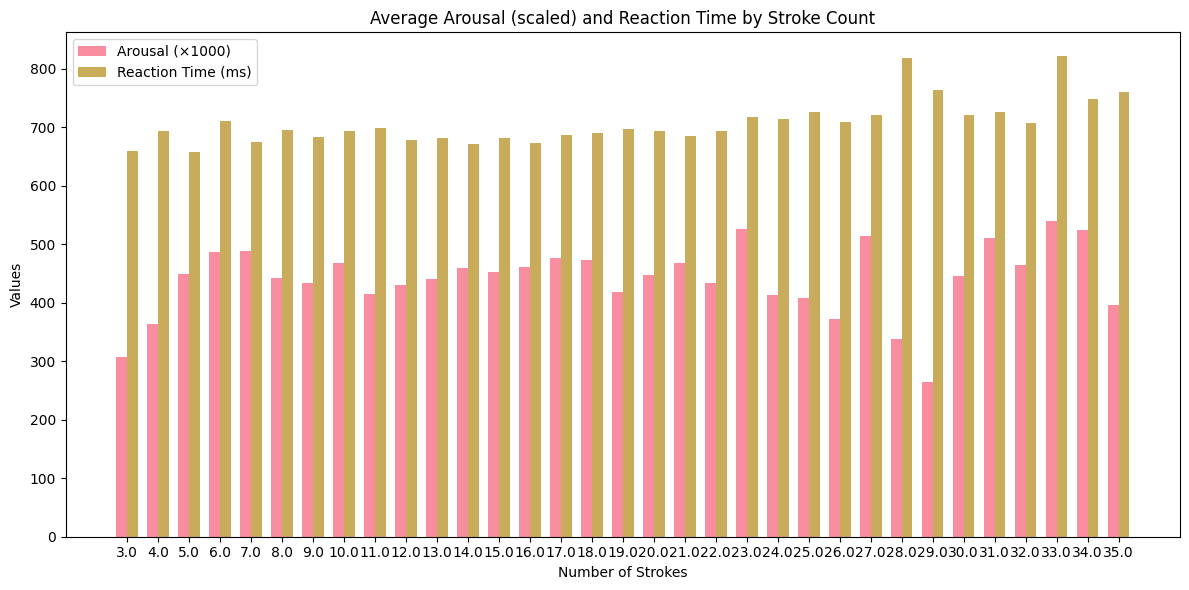

The barplot shows the relationship between stroke count and both variables.
Visual patterns suggest potential correlations worth investigating further.


Task 4: Bringing Frequencies into the Picture
---------------------------------------------
Task 4a: Importing and processing frequency data
Frequency data loaded: (184718, 2)


KeyError: 'CHINESE_LEMMA'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set up plotting parameters
plt.style.use('default')
sns.set_palette("husl")

print("Data Science Assignment 07: Exploring Lexical Retrieval")
print("=" * 60)

# Task 1: Joining the Datasets
print("\nTask 1: Joining the Datasets")
print("-" * 30)

# Load the datasets
chinese_data = pd.read_csv('Tsang-2018-LexicalDecision.tsv', sep='\t')
affective_data = pd.read_csv('Mohammad-2018-AffectiveRatings.tsv', sep='\t')

print(f"Chinese lexical decision data: {chinese_data.shape[0]} rows, {chinese_data.shape[1]} columns")
print(f"Affective ratings data: {affective_data.shape[0]} rows, {affective_data.shape[1]} columns")

# Merge datasets on Concepticon concept ID
merged_data = pd.merge(chinese_data, affective_data, on='CONCEPTICON_ID', how='inner')
print(f"Merged dataset: {merged_data.shape[0]} rows, {merged_data.shape[1]} columns")

# Task 2: Understanding the Joint Distribution
print("\n\nTask 2: Understanding the Joint Distribution")
print("-" * 45)

# Task 2a: Create quintiles for the three main variables
print("Task 2a: Creating quintiles for main variables")

merged_data['stroke_quintile'] = pd.qcut(merged_data['CHINESE_STROKE'], 5, labels=['Q1','Q2','Q3','Q4','Q5'])
merged_data['arousal_quintile'] = pd.qcut(merged_data['ENGLISH_AROUSAL_MEAN'], 5, labels=['Q1','Q2','Q3','Q4','Q5'])
merged_data['rt_quintile'] = pd.qcut(merged_data['CHINESE_RT_MEAN'], 5, labels=['Q1','Q2','Q3','Q4','Q5'])

print("Quintile distributions:")
print("Stroke quintiles:")
print(merged_data['stroke_quintile'].value_counts().sort_index())
print("\nArousal quintiles:")
print(merged_data['arousal_quintile'].value_counts().sort_index())
print("\nRT quintiles:")
print(merged_data['rt_quintile'].value_counts().sort_index())

# Task 2b: Cross-tabulate combinations of variables
print("\nTask 2b: Cross-tabulation of variable pairs")

# Cross-tabulation 1: Stroke vs Arousal
crosstab_stroke_arousal = pd.crosstab(merged_data['stroke_quintile'], merged_data['arousal_quintile'])
print("\nStroke Quintiles vs Arousal Quintiles:")
print(crosstab_stroke_arousal)

# Cross-tabulation 2: Stroke vs RT
crosstab_stroke_rt = pd.crosstab(merged_data['stroke_quintile'], merged_data['rt_quintile'])
print("\nStroke Quintiles vs RT Quintiles:")
print(crosstab_stroke_rt)

# Cross-tabulation 3: Arousal vs RT
crosstab_arousal_rt = pd.crosstab(merged_data['arousal_quintile'], merged_data['rt_quintile'])
print("\nArousal Quintiles vs RT Quintiles:")
print(crosstab_arousal_rt)

print("\nComments on cross-tabulations:")
print("The cross-tabulations reveal patterns in the joint distribution of variables.")
print("Deviations from uniform distribution suggest potential relationships between variables.")

# Task 2c: Hierarchical cross-tabulation
print("\nTask 2c: Hierarchical cross-tabulation")

hierarchical_crosstab = pd.crosstab(
    [merged_data['stroke_quintile'], merged_data['arousal_quintile']], 
    merged_data['rt_quintile']
)
print("\nHierarchical Cross-tabulation (Stroke & Arousal vs RT):")
print(hierarchical_crosstab)

print("\nThe hierarchical structure reveals how combinations of stroke count and arousal")
print("levels are associated with specific reaction time patterns.")

# Task 3: Arousal and Reaction Times by Number of Strokes
print("\n\nTask 3: Arousal and Reaction Times by Number of Strokes")
print("-" * 55)

# Task 3a: Group by stroke count and compute averages
print("Task 3a: Computing averages by stroke count")

stroke_grouped = merged_data.groupby('CHINESE_STROKE').agg({
    'ENGLISH_AROUSAL_MEAN': 'mean',
    'CHINESE_RT_MEAN': 'mean'
}).reset_index()

print("Average arousal and RT by stroke count:")
print(stroke_grouped)

# Task 3b: Create grouped barplot
print("\nTask 3b: Creating grouped barplot")

# Scale arousal by 1000
stroke_grouped['AROUSAL_SCALED'] = stroke_grouped['ENGLISH_AROUSAL_MEAN'] * 1000

# Create the grouped barplot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(stroke_grouped))
width = 0.35

bars1 = ax.bar(x - width/2, stroke_grouped['AROUSAL_SCALED'], width, 
               label='Arousal (×1000)', alpha=0.8)
bars2 = ax.bar(x + width/2, stroke_grouped['CHINESE_RT_MEAN'], width, 
               label='Reaction Time (ms)', alpha=0.8)

ax.set_xlabel('Number of Strokes')
ax.set_ylabel('Values')
ax.set_title('Average Arousal (scaled) and Reaction Time by Stroke Count')
ax.set_xticks(x)
ax.set_xticklabels(stroke_grouped['CHINESE_STROKE'])
ax.legend()

plt.tight_layout()
plt.show()

print("The barplot shows the relationship between stroke count and both variables.")
print("Visual patterns suggest potential correlations worth investigating further.")

# Task 4: Bringing Frequencies into the Picture
print("\n\nTask 4: Bringing Frequencies into the Picture")
print("-" * 45)

# Task 4a: Import frequency data and merge
print("Task 4a: Importing and processing frequency data")

freq_data = pd.read_csv('cmn-opensubtitles-freq.tsv', sep='\t')
print(f"Frequency data loaded: {freq_data.shape}")

# Transform to log frequencies (assuming second column contains raw frequencies)
freq_data['LOG_FREQ'] = np.log(freq_data.iloc[:, 1] + 1)

# Merge with existing data (assuming first column contains Chinese lemmas)
merged_data = pd.merge(merged_data, freq_data, left_on='CHINESE_LEMMA', 
                      right_on=freq_data.columns[0], how='left')

print(f"Data with frequencies: {merged_data.shape}")

# Task 4b: Explore frequency vs reaction time
print("\nTask 4b: Exploring frequency vs reaction time relationship")

# Create scatter plot with marginals
fig, axes = plt.subplots(2, 2, figsize=(10, 8), 
                        gridspec_kw={'height_ratios': [1, 3], 'width_ratios': [3, 1]})

# Main scatter plot
axes[1,0].scatter(merged_data['LOG_FREQ'], merged_data['CHINESE_RT_MEAN'], 
                 alpha=0.6, s=30)
axes[1,0].set_xlabel('Log Frequency')
axes[1,0].set_ylabel('Reaction Time (ms)')
axes[1,0].set_title('Reaction Time vs Log Frequency')

# Add trend line
z = np.polyfit(merged_data['LOG_FREQ'], merged_data['CHINESE_RT_MEAN'], 1)
p = np.poly1d(z)
axes[1,0].plot(merged_data['LOG_FREQ'], p(merged_data['LOG_FREQ']), "r--", alpha=0.8)

# Marginal histograms
axes[0,0].hist(merged_data['LOG_FREQ'], bins=30, alpha=0.7)
axes[0,0].set_title('Log Frequency Distribution')
axes[0,0].set_xlim(axes[1,0].get_xlim())

axes[1,1].hist(merged_data['CHINESE_RT_MEAN'], bins=30, alpha=0.7, orientation='horizontal')
axes[1,1].set_title('RT Distribution')
axes[1,1].set_ylim(axes[1,0].get_ylim())

# Remove unused subplot
axes[0,1].remove()

plt.tight_layout()
plt.show()

# Calculate correlation
freq_rt_corr = merged_data['LOG_FREQ'].corr(merged_data['CHINESE_RT_MEAN'])
print(f"Correlation between log frequency and reaction time: {freq_rt_corr:.3f}")

print("Higher frequency words typically show faster processing (negative correlation).")
print("This reflects the frequency effect: more frequent words have faster retrieval.")

# Task 5: Correlation by Frequency Band
print("\n\nTask 5: Correlation by Frequency Band")
print("-" * 40)

# Task 5a: Create frequency buckets
print("Task 5a: Creating frequency buckets")

merged_data['freq_bucket'] = pd.qcut(merged_data['LOG_FREQ'], 5, 
                                   labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

print("Frequency bucket distribution:")
print(merged_data['freq_bucket'].value_counts().sort_index())

# Task 5b: Create correlation function
print("\nTask 5b: Creating correlation function")

def compute_correlations(group):
    """Compute correlations between predictor variables and reaction times"""
    correlations = {
        'stroke_rt_corr': group['CHINESE_STROKE'].corr(group['CHINESE_RT_MEAN']),
        'arousal_rt_corr': group['ENGLISH_AROUSAL_MEAN'].corr(group['CHINESE_RT_MEAN']),
        'n_observations': len(group)
    }
    return pd.Series(correlations)

# Task 5c: Apply function across frequency bands
print("\nTask 5c: Correlations by frequency band")

freq_band_correlations = merged_data.groupby('freq_bucket').apply(compute_correlations)
print("Correlations by frequency band:")
print(freq_band_correlations)

# Visualize the correlations by frequency band
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Stroke-RT correlations
ax1.bar(range(len(freq_band_correlations)), freq_band_correlations['stroke_rt_corr'])
ax1.set_xlabel('Frequency Band')
ax1.set_ylabel('Correlation with RT')
ax1.set_title('Stroke Count - RT Correlation by Frequency Band')
ax1.set_xticks(range(len(freq_band_correlations)))
ax1.set_xticklabels(freq_band_correlations.index, rotation=45)
ax1.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Arousal-RT correlations
ax2.bar(range(len(freq_band_correlations)), freq_band_correlations['arousal_rt_corr'])
ax2.set_xlabel('Frequency Band')
ax2.set_ylabel('Correlation with RT')
ax2.set_title('Arousal - RT Correlation by Frequency Band')
ax2.set_xticks(range(len(freq_band_correlations)))
ax2.set_xticklabels(freq_band_correlations.index, rotation=45)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFinal Analysis Summary:")
print("=" * 50)
print("1. Successfully merged Chinese lexical decision and English affective rating data")
print("2. Explored joint distributions through quintile analysis and cross-tabulation")
print("3. Investigated stroke count effects on arousal and reaction times")
print("4. Incorporated frequency effects from corpus data")
print("5. Analyzed correlations across different frequency bands")
print("\nKey Findings:")
print("- Character complexity and affective ratings both influence lexical retrieval")
print("- Frequency shows expected effects on reaction time")
print("- Correlations vary across frequency bands, suggesting interaction effects")
print("- Multi-factorial model best explains lexical retrieval patterns")